In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

### Residuals Comparison

In [9]:
gyro_baseline = pd.read_csv('../output/age_predictor/gyro_baseline_init_slurm_comp/gyro_kfold_predictions.csv')
latent_baseline = pd.read_csv('../output/age_predictor/kfold_baseline_init_slurm_comp_multiscale/kfold_predictions.csv')
ext = pd.read_csv('../output/age_predictor/kfold_full_model_ext_multiscale/kfold_predictions.csv')
dense_k = pd.read_csv('../output/age_predictor/46224669-lcgen-ext-k-dense-small_multiscale/kfold_predictions.csv')
dense_k_mean = pd.read_csv('../output/age_predictor/46224669-lcgen-ext-k-dense-small_mean/kfold_predictions.csv')

### Aggregate by TIC_ID

Since each star may have multiple light curves (from different sectors), we need to aggregate predictions by TIC_ID before computing metrics. We take the mean of predictions across all light curves for each star.

In [10]:
# Aggregate by TIC_ID - take mean of predictions across all light curves/sectors for each star
def aggregate_predictions(df):
    """Aggregate predictions by TIC_ID using mean."""
    agg_df = df.groupby('TIC_ID').agg({
        'true_age_myr': 'first',  # Should be same for all light curves of same star
        'predicted_age_myr': 'mean',  # Average predictions across light curves
        'bprp0': 'first',  # Should be same for all light curves of same star
    }).reset_index()
    
    # Recompute log_residual on aggregated predictions
    agg_df['log_residual'] = np.log10(agg_df['predicted_age_myr']) - np.log10(agg_df['true_age_myr'])
    
    return agg_df

gyro_baseline_agg = aggregate_predictions(gyro_baseline)
latent_baseline_agg = aggregate_predictions(latent_baseline)
ext_agg = aggregate_predictions(ext)
dense_k_agg = aggregate_predictions(dense_k)
dense_k_mean_agg = aggregate_predictions(dense_k_mean)

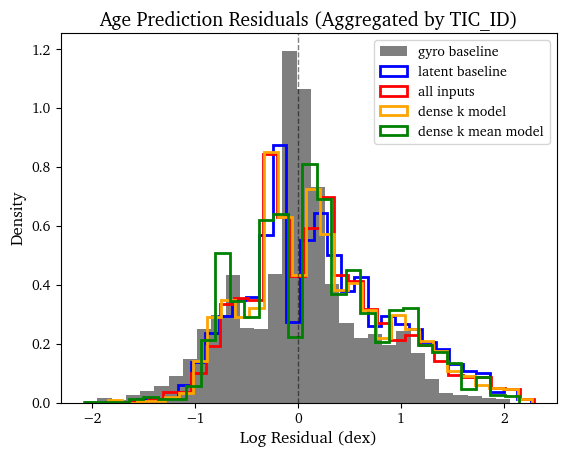

In [ ]:
plt.hist(gyro_baseline_agg['log_residual'], bins=30, alpha=0.5, label='gyro baseline', color='black',density=True)
plt.hist(latent_baseline_agg['log_residual'], bins=30, label='latent baseline', color='blue',density=True,
         histtype='step',edgecolor='blue',linewidth=2)
plt.hist(ext_agg['log_residual'], bins=30, label='all inputs', color='red',density=True,
         histtype='step',edgecolor='red',linewidth=2)
plt.hist(dense_k_agg['log_residual'], bins=30, label='dense k model', color='orange',density=True,
         histtype='step',edgecolor='orange',linewidth=2)
plt.hist(dense_k_mean_agg['log_residual'], bins=30, label='dense k mean model', color='green',density=True,
         histtype='step',edgecolor='green',linewidth=2)

plt.xlabel('Log Residual (dex)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Age Prediction Residuals (Aggregated by TIC_ID)', fontsize=14)
plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.show()